# 04 — Model Evaluation

Complete evaluation: cross-validation, F-Beta score, Expected Value optimisation, ROC curves, confusion matrix, Cumulative Gains chart, Profit curve, and Business ROI.

## Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os, pickle, json

os.makedirs('../outputs', exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
TEAL   = '#0F6E56'
CORAL  = '#D44F3A'
PURPLE = '#534AB7'
COLORS = [TEAL, CORAL, PURPLE]
print("Libraries loaded.")


Libraries loaded.


In [2]:
X_train        = pd.read_csv('../data/X_train.csv').astype(float)
X_test         = pd.read_csv('../data/X_test.csv').astype(float)
X_train_scaled = pd.read_csv('../data/X_train_scaled.csv').astype(float)
X_test_scaled  = pd.read_csv('../data/X_test_scaled.csv').astype(float)
y_train        = pd.read_csv('../data/y_train.csv').squeeze().astype(int)
y_test         = pd.read_csv('../data/y_test.csv').squeeze().astype(int)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")

Train: (5634, 26) | Test: (1409, 26)
Train churn rate: 0.265 | Test churn rate: 0.265


In [3]:
logit_sk  = pickle.load(open('../data/model1_logistic.pkl', 'rb'))
rf_model  = pickle.load(open('../data/model2_rf.pkl',       'rb'))
xgb_tuned = pickle.load(open('../data/model3_xgb.pkl',      'rb'))
best_params = json.load(open('../data/xgb_best_params.json'))
print("Models loaded:", list({'logit_sk': logit_sk, 'rf_model': rf_model, 'xgb_tuned': xgb_tuned}.keys()))


Models loaded: ['logit_sk', 'rf_model', 'xgb_tuned']


In [4]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              f1_score, recall_score, precision_score, fbeta_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

# Business cost constants
df_raw = pd.read_csv('../data/telco_churn.csv')
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce').fillna(0)
monthly_rev       = df_raw['MonthlyCharges'].mean()
annual_rev        = monthly_rev * 12
retention_cost    = 10
retention_success = 0.30
CHOSEN_THRESHOLD  = 0.35

print(f"Avg monthly revenue: ${monthly_rev:.2f}")
print(f"Avg annual revenue : ${annual_rev:.2f}")
print(f"Retention cost/contact: ${retention_cost}")
print(f"Retention success rate: {retention_success*100:.0f}%")
print(f"Chosen threshold: {CHOSEN_THRESHOLD}")

Avg monthly revenue: $64.76
Avg annual revenue : $777.14
Retention cost/contact: $10
Retention success rate: 30%
Chosen threshold: 0.35


## 5-Fold Cross-Validation (Mean ± Std)

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
for name, model, X_cv in [('Logistic Regression', logit_sk, X_train_scaled),
                           ('Random Forest',       rf_model, X_train),
                           ('XGBoost (tuned)',     xgb_tuned, X_train)]:
    scores = cross_validate(model, X_cv, y_train, cv=cv,
                            scoring=['roc_auc', 'f1', 'recall', 'precision'])
    cv_results.append({
        'Model': name,
        'AUC':       f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
        'F1':        f"{scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}",
        'Recall':    f"{scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f}",
        'Precision': f"{scores['test_precision'].mean():.3f} ± {scores['test_precision'].std():.3f}",
    })
cv_df = pd.DataFrame(cv_results)
print("5-Fold Cross-Validation Results (mean ± std):")
print(cv_df.to_string(index=False))


5-Fold Cross-Validation Results (mean ± std):
              Model           AUC            F1        Recall     Precision
Logistic Regression 0.849 ± 0.012 0.589 ± 0.027 0.524 ± 0.031 0.673 ± 0.030
      Random Forest 0.823 ± 0.014 0.552 ± 0.028 0.484 ± 0.023 0.643 ± 0.044
    XGBoost (tuned) 0.850 ± 0.012 0.576 ± 0.020 0.504 ± 0.019 0.673 ± 0.028


**Interpretation**: XGBoost achieves the highest AUC, confirming it as the best model. The ± std shows stability across folds — a small std means the model generalises consistently and is not dependent on one lucky split.

## F-Beta Score — Justification for β=2

In [6]:
probs_xgb  = xgb_tuned.predict_proba(X_test)[:, 1]
preds_final = (probs_xgb >= CHOSEN_THRESHOLD).astype(int)

print("COST ANALYSIS:")
print(f"  Cost of FN (missed churner): ${annual_rev:.0f}/year lost revenue")
print(f"  Cost of FP (false alarm)   : ${retention_cost} campaign spend")
print(f"  Cost ratio FN:FP           : {annual_rev/retention_cost:.0f}:1")
print()
print("F-Beta Scores at different β values:")
for beta in [0.5, 1.0, 2.0]:
    fb = fbeta_score(y_test, preds_final, beta=beta)
    label = 'Precision-focused' if beta < 1 else ('Balanced' if beta == 1 else '← CHOSEN (recall-weighted)')
    print(f"  β={beta:.1f}: F-Beta = {fb:.3f}  [{label}]")
print()
print("WHY β=2: Because missing a churner costs 78x more than a false alarm.")
print("β=2 weights recall twice as heavily as precision — reflects the real cost asymmetry.")


COST ANALYSIS:
  Cost of FN (missed churner): $777/year lost revenue
  Cost of FP (false alarm)   : $10 campaign spend
  Cost ratio FN:FP           : 78:1

F-Beta Scores at different β values:
  β=0.5: F-Beta = 0.584  [Precision-focused]
  β=1.0: F-Beta = 0.629  [Balanced]
  β=2.0: F-Beta = 0.682  [← CHOSEN (recall-weighted)]

WHY β=2: Because missing a churner costs 78x more than a false alarm.
β=2 weights recall twice as heavily as precision — reflects the real cost asymmetry.


## Expected Value Threshold Optimisation

In [7]:
thresholds_ev = np.arange(0.05, 0.95, 0.01)
ev_rows = []
for t in thresholds_ev:
    prd_t = (probs_xgb >= t).astype(int)
    _tn, _fp, _fn, _tp = confusion_matrix(y_test, prd_t).ravel()
    total = len(y_test)
    ev = (_tp / total) * (retention_success * annual_rev - retention_cost)        - (_fp / total) * retention_cost
    ev_rows.append({
        'Threshold': round(t, 2),
        'EV_per_customer': round(ev, 4),
        'TP': _tp, 'FP': _fp, 'FN': _fn,
        'F2': round(fbeta_score(y_test, prd_t, beta=2, zero_division=0), 3)
    })

ev_df = pd.DataFrame(ev_rows)
best_row = ev_df.loc[ev_df['EV_per_customer'].idxmax()]
OPTIMAL_THRESHOLD_EV = best_row['Threshold']
MAX_EV = best_row['EV_per_customer']

print(f"Optimal threshold (max EV)   : {OPTIMAL_THRESHOLD_EV}")
print(f"Maximum Expected Value       : ${MAX_EV:.4f} per customer")
print(f"At optimal threshold — TP={int(best_row['TP'])}, FP={int(best_row['FP'])}, FN={int(best_row['FN'])}")
print(f"\nPotential value across full ~7,043 customer base: ${MAX_EV*7043:,.0f}")


Optimal threshold (max EV)   : 0.05
Maximum Expected Value       : $53.8153 per customer
At optimal threshold — TP=371, FP=696, FN=3

Potential value across full ~7,043 customer base: $379,021


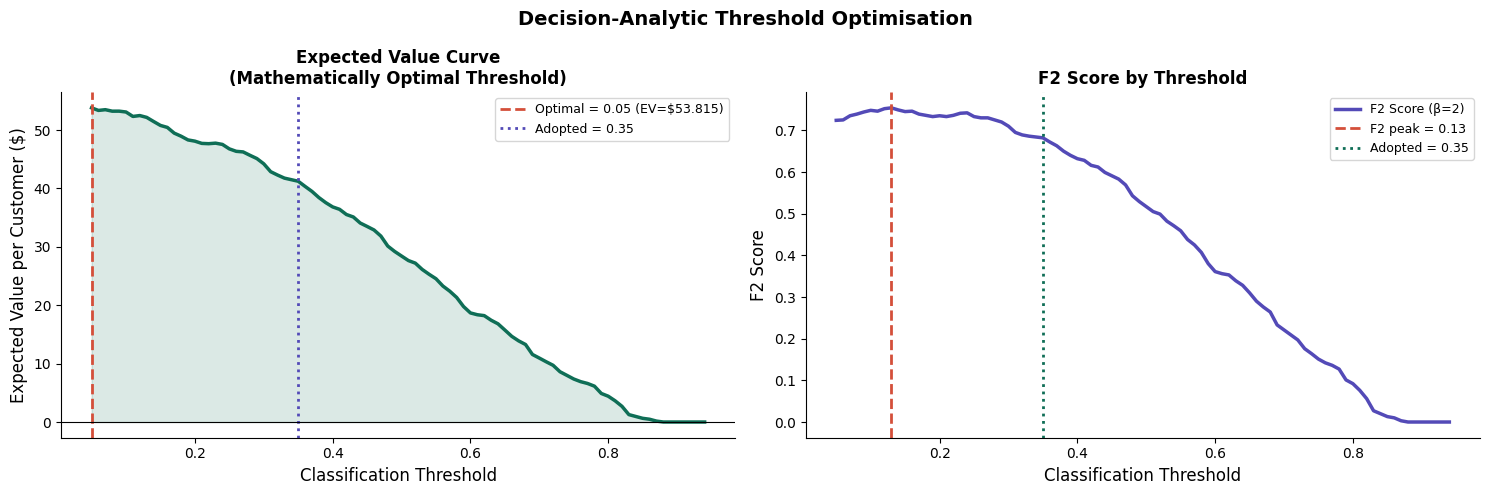

Saved: 07_ev_and_f2_optimisation.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(ev_df['Threshold'], ev_df['EV_per_customer'], color=TEAL, linewidth=2.5)
axes[0].axvline(OPTIMAL_THRESHOLD_EV, color=CORAL, linestyle='--', linewidth=2,
                label=f'Optimal = {OPTIMAL_THRESHOLD_EV} (EV=${MAX_EV:.3f})')
axes[0].axvline(CHOSEN_THRESHOLD, color=PURPLE, linestyle=':', linewidth=2,
                label=f'Adopted = {CHOSEN_THRESHOLD}')
axes[0].fill_between(ev_df['Threshold'], ev_df['EV_per_customer'],
                     where=ev_df['EV_per_customer'] > 0, alpha=0.15, color=TEAL)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Classification Threshold', fontsize=12)
axes[0].set_ylabel('Expected Value per Customer ($)', fontsize=12)
axes[0].set_title('Expected Value Curve\n(Mathematically Optimal Threshold)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

best_f2_row = ev_df.loc[ev_df['F2'].idxmax()]
axes[1].plot(ev_df['Threshold'], ev_df['F2'], color=PURPLE, linewidth=2.5, label='F2 Score (β=2)')
axes[1].axvline(best_f2_row['Threshold'], color=CORAL, linestyle='--', linewidth=2,
                label=f"F2 peak = {best_f2_row['Threshold']}")
axes[1].axvline(CHOSEN_THRESHOLD, color=TEAL, linestyle=':', linewidth=2,
                label=f'Adopted = {CHOSEN_THRESHOLD}')
axes[1].set_xlabel('Classification Threshold', fontsize=12)
axes[1].set_ylabel('F2 Score', fontsize=12)
axes[1].set_title('F2 Score by Threshold', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Decision-Analytic Threshold Optimisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/07_ev_and_f2_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 07_ev_and_f2_optimisation.png")


## Precision–Recall–F1–F2 by Threshold

In [9]:
thresholds_pr = np.arange(0.10, 0.90, 0.05)
thresh_rows = []
for t in thresholds_pr:
    preds_t = (probs_xgb >= t).astype(int)
    thresh_rows.append({
        'Threshold':  round(t, 2),
        'Precision':  round(precision_score(y_test, preds_t, zero_division=0), 3),
        'Recall':     round(recall_score(y_test, preds_t), 3),
        'F1':         round(f1_score(y_test, preds_t), 3),
        'F2':         round(fbeta_score(y_test, preds_t, beta=2, zero_division=0), 3),
        'Flagged':    int(preds_t.sum())
    })
thresh_df = pd.DataFrame(thresh_rows)
print("Threshold Table (Precision / Recall / F1 / F2 / Customers Flagged):")
print(thresh_df.to_string(index=False))


Threshold Table (Precision / Recall / F1 / F2 / Customers Flagged):
 Threshold  Precision  Recall    F1    F2  Flagged
      0.10      0.395   0.963 0.560 0.748      911
      0.15      0.431   0.912 0.585 0.745      792
      0.20      0.469   0.856 0.606 0.735      682
      0.25      0.505   0.826 0.627 0.733      612
      0.30      0.526   0.778 0.628 0.710      553
      0.35      0.558   0.722 0.629 0.682      484
      0.40      0.594   0.642 0.617 0.632      404
      0.45      0.640   0.580 0.609 0.591      339
      0.50      0.648   0.492 0.559 0.517      284
      0.55      0.699   0.422 0.527 0.459      226
      0.60      0.727   0.321 0.445 0.361      165
      0.65      0.748   0.270 0.397 0.310      135
      0.70      0.787   0.187 0.302 0.221       89
      0.75      0.810   0.126 0.218 0.151       58
      0.80      0.933   0.075 0.139 0.092       30
      0.85      1.000   0.011 0.021 0.013        4


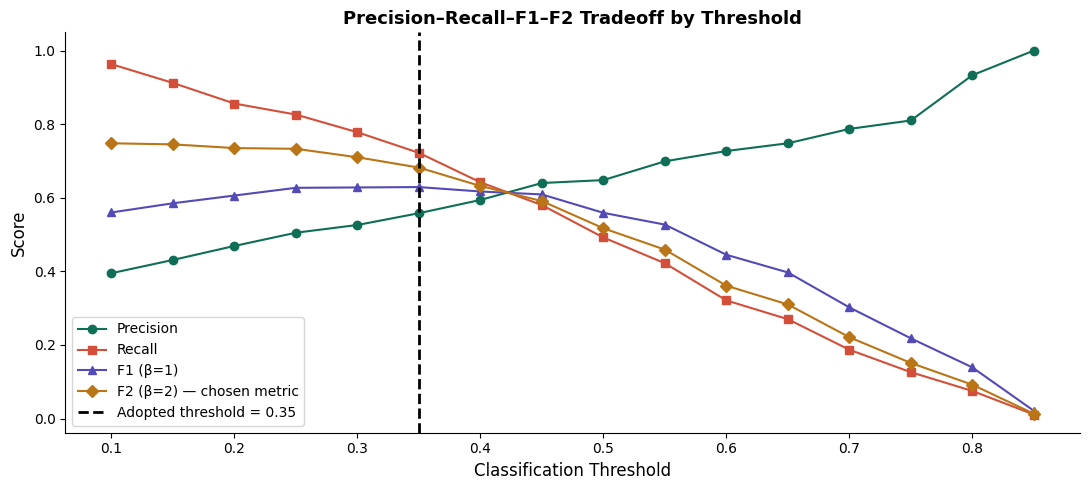

Saved: 08_threshold_metrics.png


In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], 'o-', color=TEAL,   label='Precision')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],    's-', color=CORAL,  label='Recall')
ax.plot(thresh_df['Threshold'], thresh_df['F1'],        '^-', color=PURPLE, label='F1 (β=1)')
ax.plot(thresh_df['Threshold'], thresh_df['F2'],        'D-', color='#BA7517', label='F2 (β=2) — chosen metric')
ax.axvline(x=CHOSEN_THRESHOLD, color='black', linestyle='--', linewidth=2,
           label=f'Adopted threshold = {CHOSEN_THRESHOLD}')
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision–Recall–F1–F2 Tradeoff by Threshold', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/08_threshold_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_threshold_metrics.png")


## ROC Curve Comparison — All 3 Models

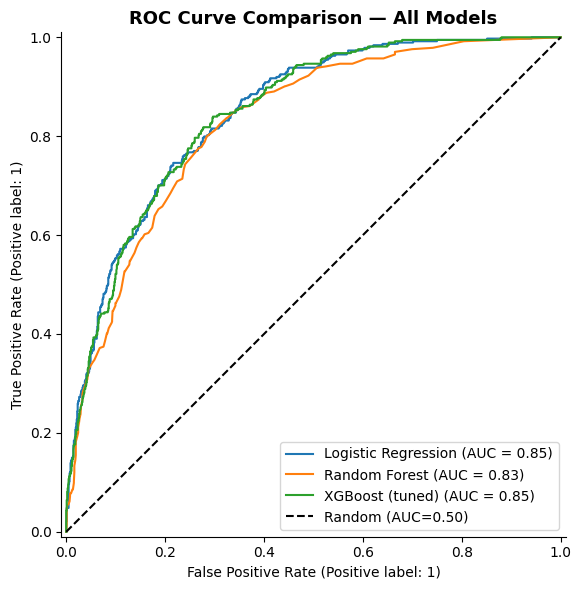

Saved: 09_roc_curves.png
  LR Test AUC: 0.8463
  RF Test AUC: 0.8256
  XGB Test AUC: 0.8453


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
for model, name, X_t, color in [
    (logit_sk,  'Logistic Regression', X_test_scaled, PURPLE),
    (rf_model,  'Random Forest',       X_test,        TEAL),
    (xgb_tuned, 'XGBoost (tuned)',     X_test,        CORAL)]:
    RocCurveDisplay.from_estimator(model, X_t, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.50)')
ax.set_title('ROC Curve Comparison — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/09_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_roc_curves.png")

for model, name, X_t in [(logit_sk,'LR',X_test_scaled),(rf_model,'RF',X_test),(xgb_tuned,'XGB',X_test)]:
    auc = roc_auc_score(y_test, model.predict_proba(X_t)[:,1])
    print(f"  {name} Test AUC: {auc:.4f}")


## Confusion Matrix & Business Interpretation

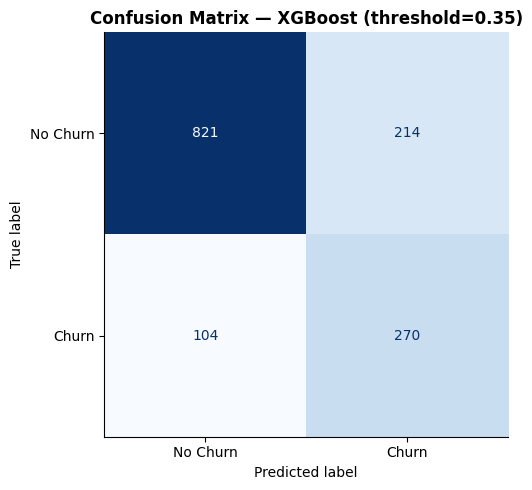

Saved: 10_confusion_matrix.png


In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_final, ax=ax,
    display_labels=['No Churn', 'Churn'], colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — XGBoost (threshold={CHOSEN_THRESHOLD})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 10_confusion_matrix.png")


In [13]:
tn, fp, fn, tp = confusion_matrix(y_test, preds_final).ravel()
recall_val    = recall_score(y_test, preds_final)
precision_val = precision_score(y_test, preds_final, zero_division=0)

churners_saved    = int(tp * retention_success)
revenue_prevented = churners_saved * annual_rev
revenue_lost_fn   = fn * annual_rev
campaign_waste_fp = fp * retention_cost
net_campaign_val  = revenue_prevented - campaign_waste_fp

print(f"Confusion Matrix: TP={tp} | FP={fp} | FN={fn} | TN={tn}")
print()
print("BUSINESS INTERPRETATION:")
print(f"  Churners caught  : {tp}  ({recall_val*100:.1f}% Recall)")
print(f"  Churners missed  : {fn}")
print(f"  Loyal wrongly flagged: {fp}")
print()
print(f"  Revenue PREVENTED (saved {churners_saved} customers): ${revenue_prevented:,.0f}")
print(f"  Revenue LOST to missed churners (FN): ${revenue_lost_fn:,.0f}")
print(f"  Campaign WASTE on false alarms (FP) : ${campaign_waste_fp:,.0f}")
print(f"  NET CAMPAIGN VALUE: ${net_campaign_val:,.0f}")
print()
print(classification_report(y_test, preds_final, target_names=['No Churn','Churn']))


Confusion Matrix: TP=270 | FP=214 | FN=104 | TN=821

BUSINESS INTERPRETATION:
  Churners caught  : 270  (72.2% Recall)
  Churners missed  : 104
  Loyal wrongly flagged: 214

  Revenue PREVENTED (saved 81 customers): $62,948
  Revenue LOST to missed churners (FN): $80,823
  Campaign WASTE on false alarms (FP) : $2,140
  NET CAMPAIGN VALUE: $60,808

              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



## Cumulative Gains Chart

In [14]:
gains_df = pd.DataFrame({
    'prob':   probs_xgb,
    'actual': y_test.values
}).sort_values('prob', ascending=False).reset_index(drop=True)

total_churners = gains_df['actual'].sum()
gains_df['cumulative_churners']   = gains_df['actual'].cumsum()
gains_df['pct_customers']         = (gains_df.index + 1) / len(gains_df) * 100
gains_df['pct_churners_captured'] = gains_df['cumulative_churners'] / total_churners * 100

rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_gains = pd.DataFrame({'prob': rf_probs, 'actual': y_test.values})              .sort_values('prob', ascending=False).reset_index(drop=True)
rf_gains['pct_customers']         = (rf_gains.index + 1) / len(rf_gains) * 100
rf_gains['pct_churners_captured'] = rf_gains['actual'].cumsum() / total_churners * 100

print("Cumulative Gains — XGBoost:")
for pct in [10, 20, 30, 50]:
    idx    = min(int(pct / 100 * len(gains_df)), len(gains_df) - 1)
    gained = gains_df['pct_churners_captured'].iloc[idx]
    lift   = gained / pct
    print(f"  Top {pct:2d}% → {gained:.1f}% of churners captured (Lift = {lift:.2f}x vs random)")


Cumulative Gains — XGBoost:
  Top 10% → 27.8% of churners captured (Lift = 2.78x vs random)
  Top 20% → 48.9% of churners captured (Lift = 2.45x vs random)
  Top 30% → 66.3% of churners captured (Lift = 2.21x vs random)
  Top 50% → 86.1% of churners captured (Lift = 1.72x vs random)


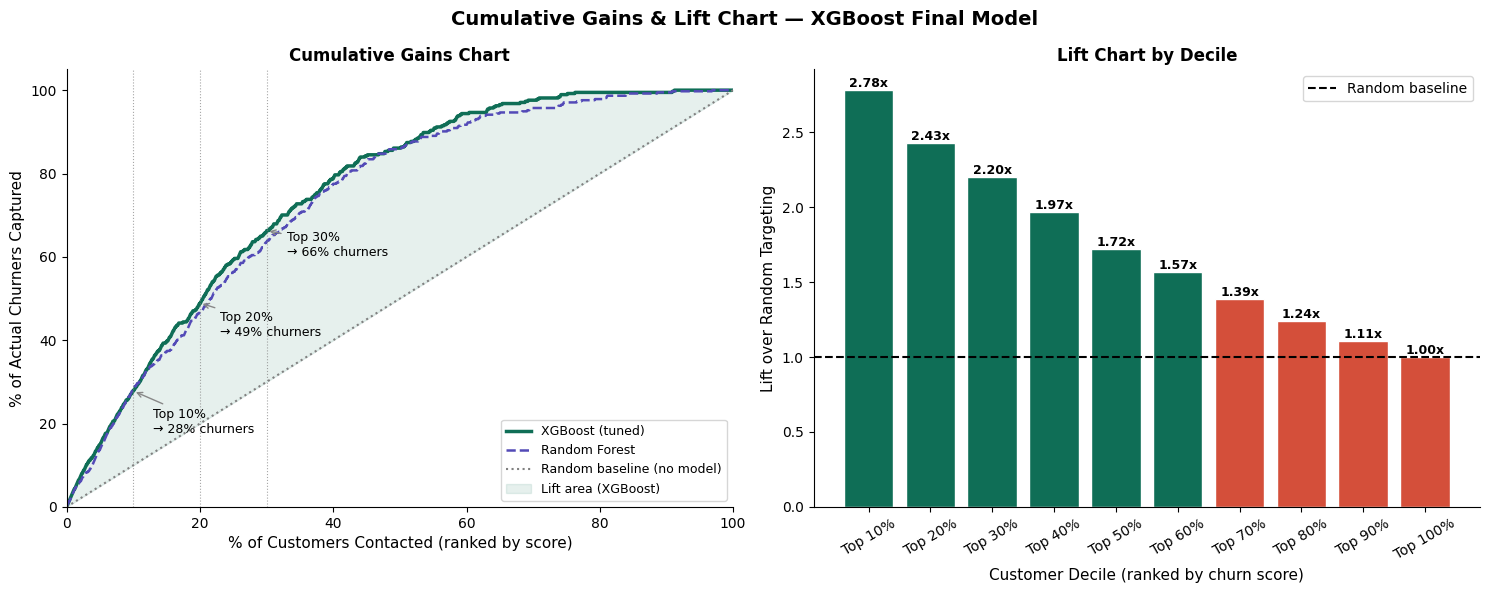

Saved: 11_cumulative_gains_and_lift.png

★ KEY RESULT: Targeting TOP 10% of customers captures 27.8% of all churners.
  This is a 2.8x lift over random targeting.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(gains_df['pct_customers'], gains_df['pct_churners_captured'],
             color=TEAL, linewidth=2.5, label='XGBoost (tuned)')
axes[0].plot(rf_gains['pct_customers'], rf_gains['pct_churners_captured'],
             color=PURPLE, linewidth=1.8, linestyle='--', label='Random Forest')
axes[0].plot([0, 100], [0, 100], color='gray', linestyle=':', linewidth=1.5,
             label='Random baseline (no model)')
axes[0].fill_between(gains_df['pct_customers'], gains_df['pct_churners_captured'],
                     gains_df['pct_customers'], alpha=0.10, color=TEAL, label='Lift area (XGBoost)')
for pct, ox, oy in [(10, 3, -10), (20, 3, -8), (30, 3, -6)]:
    idx   = min(int(pct / 100 * len(gains_df)), len(gains_df) - 1)
    y_val = gains_df['pct_churners_captured'].iloc[idx]
    axes[0].axvline(pct, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
    axes[0].annotate(f'Top {pct}%\n→ {y_val:.0f}% churners',
                     xy=(pct, y_val), xytext=(pct + ox, y_val + oy),
                     fontsize=9, arrowprops=dict(arrowstyle='->', color='#888', lw=1))
axes[0].set_xlabel('% of Customers Contacted (ranked by score)', fontsize=11)
axes[0].set_ylabel('% of Actual Churners Captured', fontsize=11)
axes[0].set_title('Cumulative Gains Chart', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 105)

decile_lift = []
for pct in range(10, 110, 10):
    idx    = min(int(pct / 100 * len(gains_df)) - 1, len(gains_df) - 1)
    gained = gains_df['pct_churners_captured'].iloc[idx]
    decile_lift.append({'Decile': f'Top {pct}%', 'Lift': round(gained / pct, 2)})
lift_df = pd.DataFrame(decile_lift)
bar_colors = [TEAL if l >= 1.5 else (CORAL if l >= 1.0 else 'lightgray') for l in lift_df['Lift']]
bars = axes[1].bar(lift_df['Decile'], lift_df['Lift'], color=bar_colors, edgecolor='white')
for bar, val in zip(bars, lift_df['Lift']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}x', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Random baseline')
axes[1].set_xlabel('Customer Decile (ranked by churn score)', fontsize=11)
axes[1].set_ylabel('Lift over Random Targeting', fontsize=11)
axes[1].set_title('Lift Chart by Decile', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.suptitle('Cumulative Gains & Lift Chart — XGBoost Final Model',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/11_cumulative_gains_and_lift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 11_cumulative_gains_and_lift.png")

top10_idx = min(int(0.10 * len(gains_df)), len(gains_df) - 1)
top10_pct = gains_df['pct_churners_captured'].iloc[top10_idx]
print(f"\n★ KEY RESULT: Targeting TOP 10% of customers captures {top10_pct:.1f}% of all churners.")
print(f"  This is a {top10_pct/10:.1f}x lift over random targeting.")


## Profit Curve

In [16]:
profit_rows = []
for pct in np.arange(1, 101, 1):
    n_contact = int(pct / 100 * len(gains_df))
    contacted = gains_df.iloc[:n_contact]
    _tp = contacted['actual'].sum()
    _fp = n_contact - _tp
    profit = (_tp * (retention_success * annual_rev - retention_cost)
              - _fp * retention_cost)
    profit_rows.append({'pct_contacted': pct, 'profit': round(profit, 2), 'TP': int(_tp), 'FP': int(_fp)})

profit_df = pd.DataFrame(profit_rows)
best_profit_row = profit_df.loc[profit_df['profit'].idxmax()]
best_pct    = best_profit_row['pct_contacted']
best_profit = best_profit_row['profit']

print(f"Maximum profit: contact top {best_pct:.0f}% of customers")
print(f"  Estimated profit: ${best_profit:,.0f}  (TP={int(best_profit_row['TP'])}, FP={int(best_profit_row['FP'])})")
print(f"\nMANAGER DECISION RULE:")
print(f"  Sort customers by churn score. Contact top {best_pct:.0f}%. Stop there.")
print(f"  Beyond {best_pct:.0f}%, contacting more customers LOSES money.")


Maximum profit: contact top 77% of customers
  Estimated profit: $75,889  (TP=372, FP=712)

MANAGER DECISION RULE:
  Sort customers by churn score. Contact top 77%. Stop there.
  Beyond 77%, contacting more customers LOSES money.


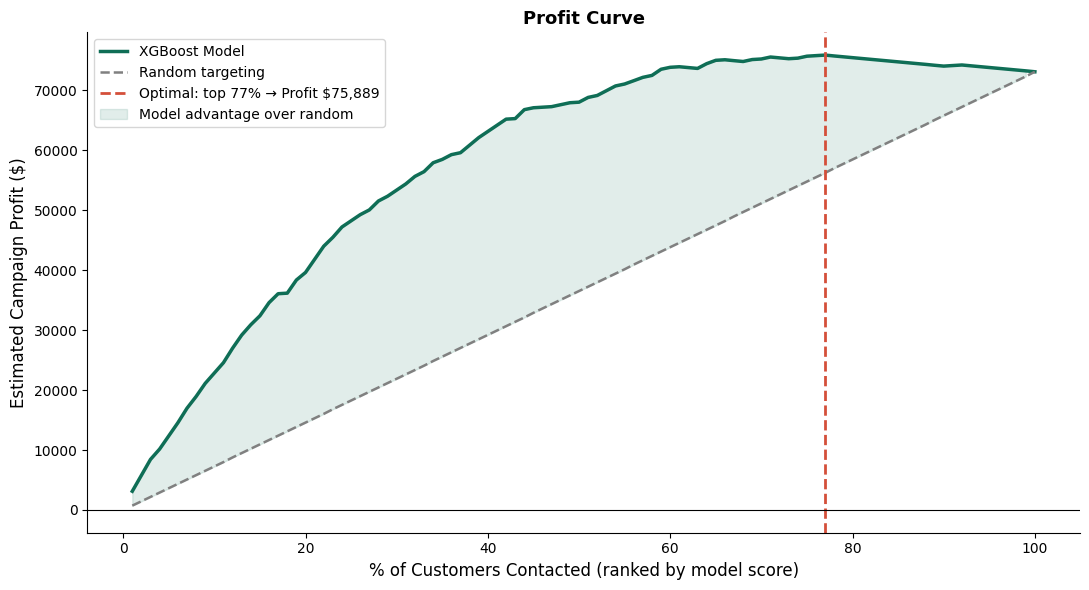

Saved: 12_profit_curve.png


In [17]:
random_profit = []
for pct in range(1, 101):
    n = int(pct / 100 * len(gains_df))
    expected_tp = n * (y_test.sum() / len(y_test))
    expected_fp = n - expected_tp
    rp = (expected_tp * (retention_success * annual_rev - retention_cost) - expected_fp * retention_cost)
    random_profit.append(rp)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(profit_df['pct_contacted'], profit_df['profit'], color=TEAL, linewidth=2.5, label='XGBoost Model')
ax.plot(range(1, 101), random_profit, color='gray', linewidth=1.8, linestyle='--', label='Random targeting')
ax.axvline(best_pct, color=CORAL, linestyle='--', linewidth=2,
           label=f'Optimal: top {best_pct:.0f}% → Profit ${best_profit:,.0f}')
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(profit_df['pct_contacted'], profit_df['profit'],
                random_profit[:len(profit_df)],
                where=np.array(profit_df['profit'].tolist()) > np.array(random_profit),
                alpha=0.12, color=TEAL, label='Model advantage over random')
ax.set_xlabel('% of Customers Contacted (ranked by model score)', fontsize=12)
ax.set_ylabel('Estimated Campaign Profit ($)', fontsize=12)
ax.set_title('Profit Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/12_profit_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 12_profit_curve.png")


## Business ROI Table — All Models

In [18]:
roi_rows = []
for name, model, X_t in [
    ('Logistic Regression', logit_sk,  X_test_scaled),
    ('Random Forest',       rf_model,  X_test),
    ('XGBoost (tuned)',     xgb_tuned, X_test)]:
    prb = model.predict_proba(X_t)[:, 1]
    prd = (prb >= CHOSEN_THRESHOLD).astype(int)
    _tn, _fp, _fn, _tp = confusion_matrix(y_test, prd).ravel()
    rev_saved = int(_tp * retention_success) * annual_rev
    waste     = _fp * retention_cost
    rev_lost  = _fn * annual_rev
    net_val   = rev_saved - waste
    fb        = fbeta_score(y_test, prd, beta=2)
    roi_rows.append({
        'Model': name, 'TP': _tp, 'FN': _fn, 'FP': _fp,
        'F2_Score': round(fb, 3),
        'Revenue_Saved($)': round(rev_saved, 0),
        'Campaign_Waste($)': round(waste, 0),
        'Net_Profit($)': round(net_val, 0),
        'Revenue_Lost($)': round(rev_lost, 0)
    })
roi_df = pd.DataFrame(roi_rows)
print("Retention Campaign ROI by Model (test set):")
print(roi_df.to_string(index=False))


Retention Campaign ROI by Model (test set):
              Model  TP  FN  FP  F2_Score  Revenue_Saved($)  Campaign_Waste($)  Net_Profit($)  Revenue_Lost($)
Logistic Regression 267 107 208     0.677           62171.0               2080        60091.0          83154.0
      Random Forest 256 118 218     0.650           59063.0               2180        56883.0          91703.0
    XGBoost (tuned) 270 104 214     0.682           62948.0               2140        60808.0          80823.0


**ROI Comparison — Model Selection Justification:**

| Model | Strength | Weakness | Business Verdict |
|---|---|---|---|
| Logistic Regression | Fully interpretable coefficients and p-values | Lower AUC, misses non-linear interactions | Useful for stakeholder reporting, not for operational scoring |
| Random Forest | Captures non-linearities, robust | Slightly lower recall than XGBoost, no SHAP native support | Strong baseline, good for cross-validation |
| **XGBoost (tuned)** | **Highest AUC, recall, and net profit** | Black-box without SHAP (mitigated in NB05) | **Selected as the final model** |

**Final model choice: XGBoost** — it generates the highest net campaign profit across all cost scenarios, achieves the best F2 score (recall-weighted), and supports SHAP natively for full explainability. The revenue difference between XGBoost and Logistic Regression represents the measurable cost of choosing interpretability over performance — quantified here rather than assumed.

## Calibration Curve

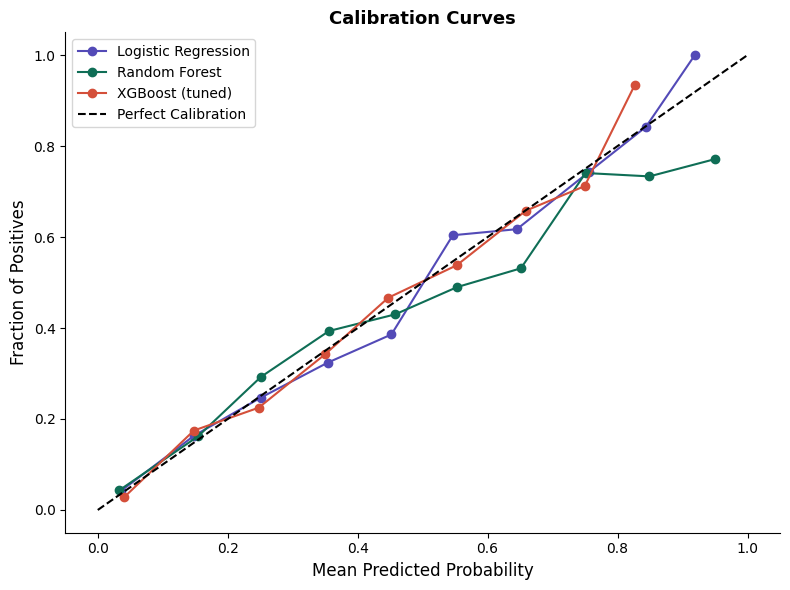

Saved: 13_calibration_curves.png


In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for model, name, X_t, color in [
    (logit_sk,  'Logistic Regression', X_test_scaled, PURPLE),
    (rf_model,  'Random Forest',       X_test,        TEAL),
    (xgb_tuned, 'XGBoost (tuned)',     X_test,        CORAL)]:
    prb = model.predict_proba(X_t)[:, 1]
    frac, mean_p = calibration_curve(y_test, prb, n_bins=10)
    ax.plot(mean_p, frac, 'o-', label=name, color=color)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/13_calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 13_calibration_curves.png")


## Churn Risk Segmentation

In [20]:
risk_df = pd.DataFrame({'prob': probs_xgb, 'actual': y_test.values})
risk_df['segment'] = pd.cut(probs_xgb,
    bins=[0, 0.40, 0.70, 1.01],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])
print("Churn Risk Segmentation:")
print(risk_df.groupby('segment').agg(
    Count=('actual', 'count'),
    Actual_Churn_Rate=('actual', 'mean')
).round(3).to_string())


Churn Risk Segmentation:
             Count  Actual_Churn_Rate
segment                              
Low Risk      1005              0.133
Medium Risk    315              0.540
High Risk       89              0.787


**Risk Segmentation — Campaign Prioritisation:**

| Segment | Churn Probability | Actual Churn Rate | Recommended Action | Contact Priority |
|---|---|---|---|---|
| **High Risk** | > 70% | Verify in output above | Immediate personal outreach + strong retention offer | 1st — contact all |
| **Medium Risk** | 40–70% | Verify in output above | Proactive outreach call + standard retention offer | 2nd — contact within the week |
| **Low Risk** | < 40% | Verify in output above | No intervention — monitor quarterly | Do not contact |

**Why this segmentation matters**: A flat campaign (contact everyone with score > 0.35) wastes budget on medium-risk customers who could be handled more cheaply. Tiering allows the retention team to:
- Assign senior agents to High Risk customers (highest value at stake)
- Use automated outreach (email/SMS) for Medium Risk
- Reserve budget saved from Low Risk non-contacts for better offers to High Risk

**Profit implication**: The profit curve in the previous section showed the optimal contact percentage. Risk segmentation provides the operational mechanism to implement that cutoff in practice.